# No. 3

**Nama:** Winston Octavianus Sugih

**NIM:** 2802403776

**Link video presentasi:** https://drive.google.com/file/d/1koWQs-p59PRxpQpl9nsZTAuakPZKbZx8/view?usp=sharing

## 1. Import Library

In [11]:
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.linalg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

## 2. Penjelasan Cara Kerja GAN (Soal 3a)

GAN (Generative Adversarial Network) terdiri dari dua jaringan yang dilatih bersamaan dan saling bertanding, yaitu Generator dan Discriminator.

1. Generator menerima sekumpulan angka acak (noise) lalu mengubahnya menjadi gambar palsu. Tujuannya membuat gambar semirip mungkin dengan gambar asli supaya bisa menipu Discriminator.

2. Discriminator menerima sebuah gambar, bisa gambar asli dari dataset atau gambar palsu dari Generator, lalu menebak apakah gambar itu asli atau palsu.

3. Keduanya dilatih bergantian. Discriminator makin pintar membedakan asli dan palsu, dan Generator makin pintar membuat gambar yang dianggap asli. Lama-lama Generator mampu menghasilkan gambar yang sulit dibedakan dari aslinya.

Pada soal 3b, arsitektur yang diminta adalah Conditional GAN. Bedanya dengan GAN biasa, label kelas ikut dimasukkan ke Generator maupun Discriminator melalui sebuah layer Embedding. Dengan begitu, Generator bisa diarahkan untuk membuat gambar dari kelas tertentu (storage_tank atau parking_lot), dan Discriminator menilai gambar dengan mempertimbangkan labelnya. Pada notebook ini Conditional GAN dilatih untuk membangkitkan gambar overhead dari dua kelas tersebut, dan kualitasnya diukur dengan FID pada data test.

## 3. Konfigurasi Dataset

In [12]:
BASE_DIR = "/kaggle/input/datasets/datamunge/overheadmnist/version2"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

SELECTED_CLASSES = ["storage_tank", "parking_lot"]

IMG_SIZE = 28
IMG_DIM = IMG_SIZE * IMG_SIZE      # img_size ** 2 = 784
N_CLASSES = len(SELECTED_CLASSES)  # n_labels = 2
LATENT_DIM = 100                   # dimensi noise

BATCH_SIZE = 128
BASELINE_EPOCHS = 60
MODIFIED_EPOCHS = 150
FID_SAMPLE = 1784                  # pakai seluruh data test supaya FID stabil

print("BASE_DIR exists :", os.path.exists(BASE_DIR))
print("TRAIN_DIR exists:", os.path.exists(TRAIN_DIR))
print("TEST_DIR exists :", os.path.exists(TEST_DIR))

BASE_DIR exists : True
TRAIN_DIR exists: True
TEST_DIR exists : True


## 4. Mengumpulkan Path Gambar

In [13]:
def collect_image_paths(base_dir, selected_classes):
    data = []
    for label_idx, class_name in enumerate(selected_classes):
        class_dir = os.path.join(base_dir, class_name)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"Folder kelas tidak ditemukan: {class_dir}")
        for path in sorted(glob.glob(os.path.join(class_dir, "*.jpg"))):
            data.append({"filepath": path, "label_name": class_name, "label": label_idx})
    return pd.DataFrame(data)


train_paths = collect_image_paths(TRAIN_DIR, SELECTED_CLASSES)
test_paths = collect_image_paths(TEST_DIR, SELECTED_CLASSES)

print("Jumlah gambar train:", len(train_paths))
print("Jumlah gambar test :", len(test_paths))
print("\nMapping label:", {name: i for i, name in enumerate(SELECTED_CLASSES)})
print("\nDistribusi train:")
display(train_paths["label_name"].value_counts())
print("Distribusi test:")
display(test_paths["label_name"].value_counts())

Jumlah gambar train: 14232
Jumlah gambar test : 1784

Mapping label: {'storage_tank': 0, 'parking_lot': 1}

Distribusi train:


label_name
storage_tank    7121
parking_lot     7111
Name: count, dtype: int64

Distribusi test:


label_name
parking_lot     896
storage_tank    888
Name: count, dtype: int64

## 5. Loading dan Scaling Data

In [14]:
def load_images_and_labels(df, img_size=28):
    images, labels = [], []
    for _, row in df.iterrows():
        img = load_img(row["filepath"], color_mode="grayscale", target_size=(img_size, img_size))
        arr = img_to_array(img).astype("float32")
        arr = (arr / 127.5) - 1.0          # scaling ke [-1, 1]
        images.append(arr)
        labels.append(row["label"])
    X = np.array(images, dtype="float32")
    y = np.array(labels, dtype="int32").reshape(-1, 1)
    return X, y


X_train, y_train = load_images_and_labels(train_paths, IMG_SIZE)
X_test, y_test = load_images_and_labels(test_paths, IMG_SIZE)

print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape, "| y_test shape :", y_test.shape)
print("Pixel min:", X_train.min(), "| Pixel max:", X_train.max())

X_train shape: (14232, 28, 28, 1) | y_train shape: (14232, 1)
X_test shape : (1784, 28, 28, 1) | y_test shape : (1784, 1)
Pixel min: -1.0 | Pixel max: 1.0


## 6. Menampilkan Contoh Data Asli per Kelas

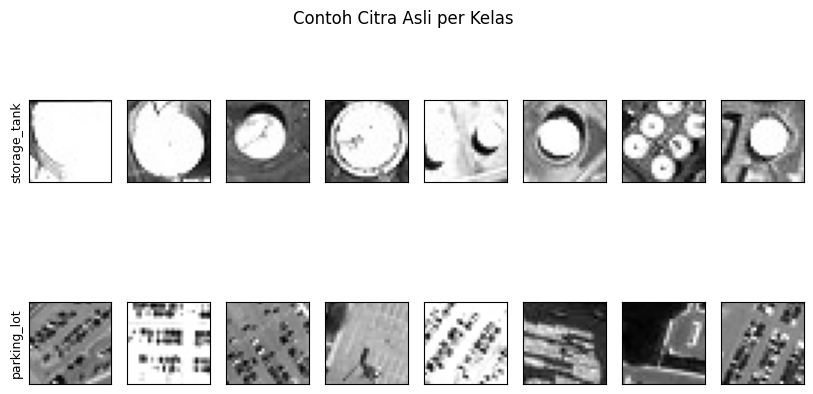

In [15]:
def show_real_per_class(X, y, n=8):
    plt.figure(figsize=(10, 2.4 * N_CLASSES))
    for cls in range(N_CLASSES):
        idx = np.where(y.flatten() == cls)[0][:n]
        for j, k in enumerate(idx):
            ax = plt.subplot(N_CLASSES, n, cls * n + j + 1)
            plt.imshow((X[k].squeeze() + 1.0) / 2.0, cmap="gray")
            plt.xticks([]); plt.yticks([])
            if j == 0:
                ax.set_ylabel(SELECTED_CLASSES[cls], fontsize=9)
    plt.suptitle("Contoh Citra Asli per Kelas")
    plt.show()


show_real_per_class(X_train, y_train, n=8)

## 7. Membuat TensorFlow Dataset

In [16]:
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(buffer_size=2048, seed=SEED)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)
print("Jumlah batch per epoch:", len(train_dataset))

Jumlah batch per epoch: 111


## 8. Generator Baseline (Conditional, sesuai diagram soal)

In [17]:
def build_baseline_generator():
    noise = layers.Input(shape=(LATENT_DIM,), name="noise")
    label = layers.Input(shape=(1,), dtype="int32", name="label")

    li = layers.Embedding(N_CLASSES, N_CLASSES)(label)   # Embedding(labels)
    li = layers.Flatten()(li)

    x = layers.Concatenate()([noise, li])                # noise + n_labels
    x = layers.Dense(128)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(IMG_DIM, activation="tanh")(x)      # Linear(1024, img_size**2)
    img = layers.Reshape((IMG_SIZE, IMG_SIZE, 1))(x)

    return models.Model([noise, label], img, name="Baseline_cGAN_Generator")


baseline_generator = build_baseline_generator()
baseline_generator.summary()

Model: "Baseline_cGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 2)      │          4 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 102)       │          0 │ noise[0][0],      │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     13,184 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 128)       │          0 │ dense_5[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │     33,024 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 256)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 512)       │    131,584 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 512)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1024)      │    525,312 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 784)       │    803,600 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28, 1) │          0 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,513,876 (5.77 MB)

 Trainable params: 1,510,292 (5.76 MB)

 Non-trainable params: 3,584 (14.00 KB)

## 9. Discriminator Baseline (Conditional, sesuai diagram soal)

In [18]:
def build_baseline_discriminator():
    img = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="image")
    label = layers.Input(shape=(1,), dtype="int32", name="label")

    li = layers.Embedding(N_CLASSES, N_CLASSES)(label)   # Embedding(labels)
    li = layers.Flatten()(li)

    x = layers.Flatten()(img)                            # img_size**2
    x = layers.Concatenate()([x, li])                    # n_labels + img_size**2

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(0.2)(x)
    out = layers.Dense(1)(x)                             # logit (from_logits=True)

    return models.Model([img, label], out, name="Baseline_cGAN_Discriminator")


baseline_discriminator = build_baseline_discriminator()
baseline_discriminator.summary()

Model: "Baseline_cGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 2)      │          4 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 784)       │          0 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 786)       │          0 │ flatten_4[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 512)       │    402,944 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 512)       │          0 │ dense_10[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1024)      │    525,312 │ leaky_re_lu_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 1024)      │          0 │ dense_11[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1024)      │          0 │ leaky_re_lu_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1024)      │  1,049,600 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 1024)      │          0 │ dense_12[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1024)      │          0 │ leaky_re_lu_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 512)       │    524,800 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 512)       │          0 │ dense_13[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1)         │        513 │ leaky_re_lu_11[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,503,173 (9.55 MB)

 Trainable params: 2,503,173 (9.55 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Kelas Conditional GAN dan Training Loop

In [ ]:
class ConditionalGAN(keras.Model):
    def __init__(self, generator, discriminator, latent_dim, n_classes):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.n_classes = n_classes
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    def compile(self, d_optimizer, g_optimizer, loss_fn, label_smoothing=0.0):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.label_smoothing = label_smoothing

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, data):
        real_images, real_labels = data
        batch_size = tf.shape(real_images)[0]

        # Latih Discriminator
        noise = tf.random.normal([batch_size, self.latent_dim])
        fake_labels = tf.random.uniform([batch_size, 1], 0, self.n_classes, dtype=tf.int32)
        generated = self.generator([noise, fake_labels], training=True)
        with tf.GradientTape() as tape:
            real_pred = self.discriminator([real_images, real_labels], training=True)
            fake_pred = self.discriminator([generated, fake_labels], training=True)
            real_target = tf.ones_like(real_pred) * (1.0 - self.label_smoothing)
            fake_target = tf.zeros_like(fake_pred)
            d_loss = self.loss_fn(real_target, real_pred) + self.loss_fn(fake_target, fake_pred)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        # Latih Generator
        noise = tf.random.normal([batch_size, self.latent_dim])
        fake_labels = tf.random.uniform([batch_size, 1], 0, self.n_classes, dtype=tf.int32)
        with tf.GradientTape() as tape:
            generated = self.generator([noise, fake_labels], training=True)
            fake_pred = self.discriminator([generated, fake_labels], training=True)
            g_loss = self.loss_fn(tf.ones_like(fake_pred), fake_pred)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}

## 11. Fungsi Evaluasi FID (pada data test)

In [20]:
inception_model = InceptionV3(include_top=False, pooling="avg", input_shape=(299, 299, 3))


def get_inception_features(images, batch_size=64):
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        batch = (batch + 1.0) * 127.5
        batch = tf.convert_to_tensor(batch, dtype=tf.float32)
        batch = tf.image.grayscale_to_rgb(batch)
        batch = tf.image.resize(batch, (299, 299))
        batch = preprocess_input(batch)
        features.append(inception_model.predict(batch, verbose=0))
    return np.concatenate(features, axis=0)


def calculate_fid(real_images, fake_images):
    f_real = get_inception_features(real_images)
    f_fake = get_inception_features(fake_images)
    mu_r, sigma_r = f_real.mean(axis=0), np.cov(f_real, rowvar=False)
    mu_g, sigma_g = f_fake.mean(axis=0), np.cov(f_fake, rowvar=False)
    diff = mu_r - mu_g
    covmean, _ = scipy.linalg.sqrtm(sigma_r.dot(sigma_g), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma_r + sigma_g - 2.0 * covmean))


def evaluate_fid(generator, X_real, y_real, n_sample=FID_SAMPLE):
    n = min(n_sample, len(X_real))
    idx = np.random.choice(len(X_real), n, replace=False)
    real_sample = X_real[idx]
    label_sample = y_real[idx].reshape(-1, 1)
    noise = tf.random.normal([n, LATENT_DIM])
    fake_sample = generator.predict([noise, label_sample], verbose=0)
    return calculate_fid(real_sample, fake_sample)

## 12. Training Baseline Conditional GAN

In [21]:
baseline_gan = ConditionalGAN(baseline_generator, baseline_discriminator, LATENT_DIM, N_CLASSES)
baseline_gan.compile(
    d_optimizer=Adam(learning_rate=2e-4, beta_1=0.5),
    g_optimizer=Adam(learning_rate=2e-4, beta_1=0.5),
    loss_fn=BinaryCrossentropy(from_logits=True),
    label_smoothing=0.0
)

baseline_history = baseline_gan.fit(train_dataset, epochs=BASELINE_EPOCHS, verbose=1)

Epoch 1/60


I0000 00:00:1782482862.310650     129 service.cc:152] XLA service 0x7e4d30002e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782482862.310715     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782482862.310722     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782482863.248228     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


 22/111 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - d_loss: 1.0333 - g_loss: 1.3760

I0000 00:00:1782482870.794473     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - d_loss: 1.0261 - g_loss: 2.9441
Epoch 2/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - d_loss: 1.2028 - g_loss: 1.7685
Epoch 3/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - d_loss: 1.1916 - g_loss: 1.4348
Epoch 4/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - d_loss: 1.1939 - g_loss: 1.3754
Epoch 5/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - d_loss: 1.1451 - g_loss: 1.4115
Epoch 6/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - d_loss: 1.0656 - g_loss: 1.5468
Epoch 7/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - d_loss: 1.0060 - g_loss: 1.8970
Epoch 8/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - d_loss: 1.0526 - g_loss: 1.7366
Epoch 9/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - d_loss: 0.9756 - g_loss: 2.0516
Epoch 10/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - d_loss: 0.9566 - g_loss: 2.0426
Epoch 11/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - d_loss: 0.9396 - g_loss: 1.9726
Epoch 12/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - d_loss:

## 13. Visualisasi Loss dan Hasil Generate Baseline per Kelas

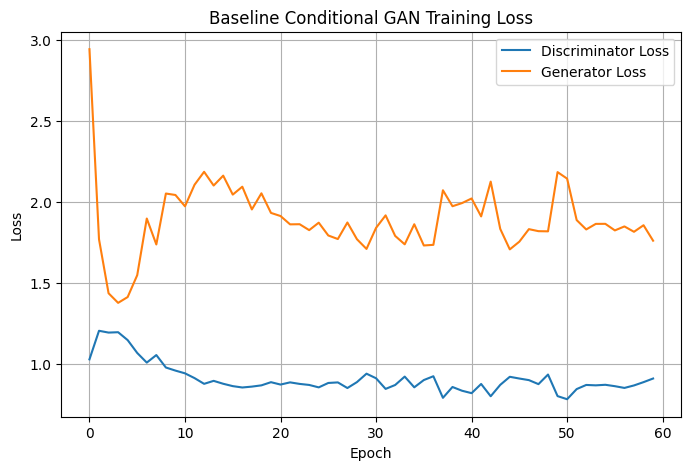

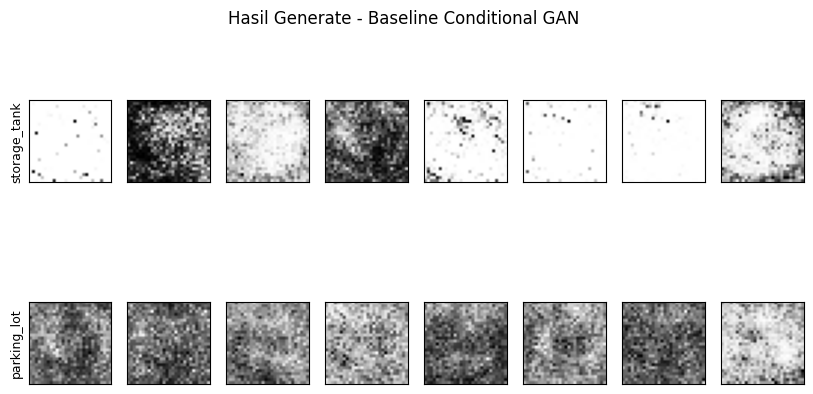

In [22]:
def plot_gan_loss(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["d_loss"], label="Discriminator Loss")
    plt.plot(history.history["g_loss"], label="Generator Loss")
    plt.title(title)
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True)
    plt.show()


def show_generated_per_class(generator, title, n=8):
    plt.figure(figsize=(10, 2.4 * N_CLASSES))
    for cls in range(N_CLASSES):
        noise = tf.random.normal([n, LATENT_DIM])
        labels = tf.fill([n, 1], cls)
        gen = generator.predict([noise, labels], verbose=0)
        for j in range(n):
            ax = plt.subplot(N_CLASSES, n, cls * n + j + 1)
            plt.imshow((gen[j].squeeze() + 1.0) / 2.0, cmap="gray")
            plt.xticks([]); plt.yticks([])
            if j == 0:
                ax.set_ylabel(SELECTED_CLASSES[cls], fontsize=9)
    plt.suptitle(title)
    plt.show()


plot_gan_loss(baseline_history, "Baseline Conditional GAN Training Loss")
show_generated_per_class(baseline_generator, "Hasil Generate - Baseline Conditional GAN", n=8)

## 14. Evaluasi FID Baseline (pada Data Test)

In [23]:
baseline_fid = evaluate_fid(baseline_generator, X_test, y_test)
print("Baseline Conditional GAN - FID:", baseline_fid)

Baseline Conditional GAN - FID: 282.75374176866796


## 15. Modifikasi Arsitektur (Soal 3c)

In [24]:
def build_modified_generator():
    noise = layers.Input(shape=(LATENT_DIM,), name="noise")
    label = layers.Input(shape=(1,), dtype="int32", name="label")

    li = layers.Embedding(N_CLASSES, 50)(label)
    li = layers.Flatten()(li)
    x = layers.Concatenate()([noise, li])

    x = layers.Dense(7 * 7 * 256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((7, 7, 256))(x)

    x = layers.UpSampling2D()(x)                                   # 14x14
    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.UpSampling2D()(x)                                   # 28x28
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    img = layers.Conv2D(1, 3, padding="same", activation="tanh")(x)
    return models.Model([noise, label], img, name="Modified_cGAN_Generator")


def build_modified_discriminator():
    img = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="image")
    label = layers.Input(shape=(1,), dtype="int32", name="label")

    # Jalur convolutional fokus murni ke citra (tanpa label di input)
    x = layers.Conv2D(64, 4, strides=2, padding="same")(img)       # 14x14
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)        # 7x7
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, 4, strides=2, padding="same")(x)        # 4x4
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)

    # Conditioning secara late fusion: label digabung setelah ekstraksi fitur
    li = layers.Embedding(N_CLASSES, 50)(label)
    li = layers.Flatten()(li)
    x = layers.Concatenate()([x, li])

    out = layers.Dense(1)(x)
    return models.Model([img, label], out, name="Modified_cGAN_Discriminator")


modified_generator = build_modified_generator()
modified_discriminator = build_modified_discriminator()
modified_generator.summary()
modified_discriminator.summary()

Model: "Modified_cGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 50)     │        100 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 50)        │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 150)       │          0 │ noise[0][0],      │
│ (Concatenate)       │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 12544)     │  1,881,600 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12544)     │     50,176 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 12544)     │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 7, 7, 256) │          0 │ leaky_re_lu_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 14, 14,    │          0 │ reshape_1[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_188 (Conv2D) │ (None, 14, 14,    │    294,912 │ up_sampling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_188[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 28, 28,    │          0 │ leaky_re_lu_13[0… │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 28, 28,    │     73,728 │ up_sampling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_189[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_190 (Conv2D) │ (None, 28, 28,    │     18,432 │ leaky_re_lu_14[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,320,133 (8.85 MB)

 Trainable params: 2,294,597 (8.75 MB)

 Non-trainable params: 25,536 (99.75 KB)

Model: "Modified_cGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_192 (Conv2D) │ (None, 14, 14,    │      1,088 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_16      │ (None, 14, 14,    │          0 │ conv2d_192[0][0]  │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 14, 14,    │          0 │ leaky_re_lu_16[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_193 (Conv2D) │ (None, 7, 7, 128) │    131,200 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_193[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_17      │ (None, 7, 7, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_194 (Conv2D) │ (None, 4, 4, 256) │    524,544 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 256) │      1,024 │ conv2d_194[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_18      │ (None, 4, 4, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 4, 4, 256) │          0 │ leaky_re_lu_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 50)     │        100 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 4096)      │          0 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 50)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 4146)      │          0 │ flatten_6[0][0],  │
│ (Concatenate)       │                   │            │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │      4,147 │ concatenate_8[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 662,615 (2.53 MB)

 Trainable params: 661,847 (2.52 MB)

 Non-trainable params: 768 (3.00 KB)

## 16. Training Modified Conditional GAN

In [25]:
modified_gan = ConditionalGAN(modified_generator, modified_discriminator, LATENT_DIM, N_CLASSES)
modified_gan.compile(
    d_optimizer=Adam(learning_rate=1e-4, beta_1=0.5),
    g_optimizer=Adam(learning_rate=2e-4, beta_1=0.5),
    loss_fn=BinaryCrossentropy(from_logits=True),
    label_smoothing=0.1
)

modified_history = modified_gan.fit(train_dataset, epochs=MODIFIED_EPOCHS, verbose=1)

Epoch 1/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - d_loss: 1.4368 - g_loss: 1.1735
Epoch 2/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - d_loss: 1.5421 - g_loss: 0.9245
Epoch 3/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - d_loss: 1.4368 - g_loss: 0.9611
Epoch 4/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - d_loss: 1.4313 - g_loss: 0.9818
Epoch 5/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - d_loss: 1.4467 - g_loss: 0.9176
Epoch 6/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - d_loss: 1.4280 - g_loss: 0.9291
Epoch 7/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - d_loss: 1.4011 - g_loss: 0.9321
Epoch 8/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - d_loss: 1.3982 - g_loss: 0.9345
Epoch 9/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - d_loss: 1.4168 - g_loss: 0.9334
Epoch 10/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - d_loss: 1.4078 - g_loss: 0.9151
Epoch 11/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - d_loss: 1.3914 - g_loss: 0.9198
Epoch 12/150
111/111 ━━━━━━━━

## 17. Visualisasi Loss dan Hasil Generate Modified per Kelas

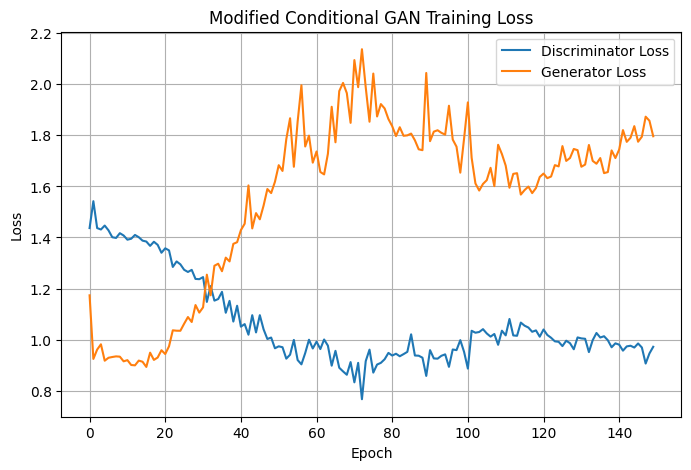

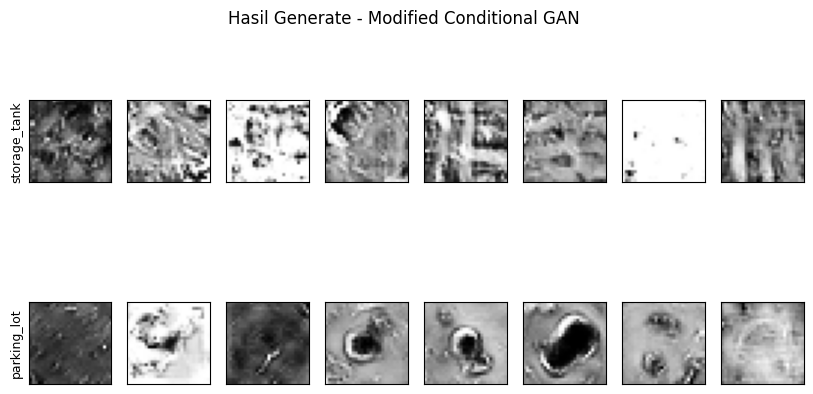

In [26]:
plot_gan_loss(modified_history, "Modified Conditional GAN Training Loss")
show_generated_per_class(modified_generator, "Hasil Generate - Modified Conditional GAN", n=8)

## 18. Evaluasi FID Modified (pada Data Test)

In [27]:
modified_fid = evaluate_fid(modified_generator, X_test, y_test)
print("Modified Conditional GAN - FID:", modified_fid)

Modified Conditional GAN - FID: 202.13324677452627


## 19. Perbandingan Baseline vs Modified

In [28]:
results_df = pd.DataFrame([
    {"Model": "Baseline cGAN (MLP)", "FID": baseline_fid},
    {"Model": "Modified cGAN (Conv)", "FID": modified_fid},
])
display(results_df)

best_model = results_df.sort_values("FID", ascending=True).iloc[0]
print("Model terbaik berdasarkan FID (semakin kecil semakin baik):")
print(best_model["Model"], "dengan FID", round(best_model["FID"], 4))

,Model,FID
0,Baseline cGAN (MLP),282.753742
1,Modified cGAN (Conv),202.133247


Model terbaik berdasarkan FID (semakin kecil semakin baik):
Modified cGAN (Conv) dengan FID 202.1332


## 20. Analisis Hasil

Dataset yang dipakai adalah dua kelas Overhead-MNIST, yaitu storage_tank dan parking_lot, sesuai pembagian NIM genap dan laki-laki. Gambar asli diambil dari folder train untuk melatih GAN dan folder test sebagai acuan FID. Semua gambar diubah ke grayscale 28 x 28 dan di-scaling ke rentang -1 sampai 1.

Arsitektur yang dibangun adalah Conditional GAN sesuai diagram pada soal 3b. Baseline memakai layer Linear (MLP) dengan label kelas dimasukkan lewat Embedding ke Generator dan Discriminator, sesuai dimensi yang tertera pada diagram. Modified mengganti layer Linear dengan layer convolutional (Conditional DCGAN) namun tetap conditional, dan ditambah one-sided label smoothing, TTUR, serta training yang lebih lama.

Baseline memiliki FID 282 sementara modified dapat FID 202. Oleh karena itu Modified menjadi model terbaik.

Nilai FID di sini cenderung besar secara absolut, dan ini wajar. InceptionV3 yang dipakai untuk menghitung FID dilatih pada foto natural berwarna, sedangkan gambar di sini grayscale overhead 28 x 28, sehingga ada perbedaan domain. Karena itu yang dinilai adalah perbandingan relatifnya, yaitu modified lebih kecil dari baseline, bukan nilai absolutnya.

## 21. Kesimpulan

Eksperimen ini membangun Conditional GAN sesuai diagram soal 3b untuk membangkitkan gambar dua kelas Overhead-MNIST (storage_tank dan parking_lot). Label kelas dimasukkan ke Generator dan Discriminator lewat Embedding, sehingga gambar yang dihasilkan dapat diarahkan per kelas.

Baseline memakai arsitektur Linear (MLP) sesuai diagram, lalu dievaluasi dengan FID pada data test. Modified mengubahnya menjadi Conditional DCGAN dengan layer convolutional, ditambah label smoothing, TTUR, dan training lebih lama, untuk mendapatkan FID yang lebih kecil. Model dengan FID lebih rendah dipilih sebagai yang terbaik karena menghasilkan distribusi gambar yang paling mirip dengan gambar asli.